## EN3160 Assignment 1
### Intensity Transformations and Neighborhood Filtering

- Name : Ahamed A.M.S
- Index No : 230020R
- GitHub : https://github.com/shaahidahamed (https://github.com/shaahidahamed/EN3160-Image-Processing-and-Machine-Vision/tree/main/Assignments/Assignment-1)

<img src="Q1.png" />

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

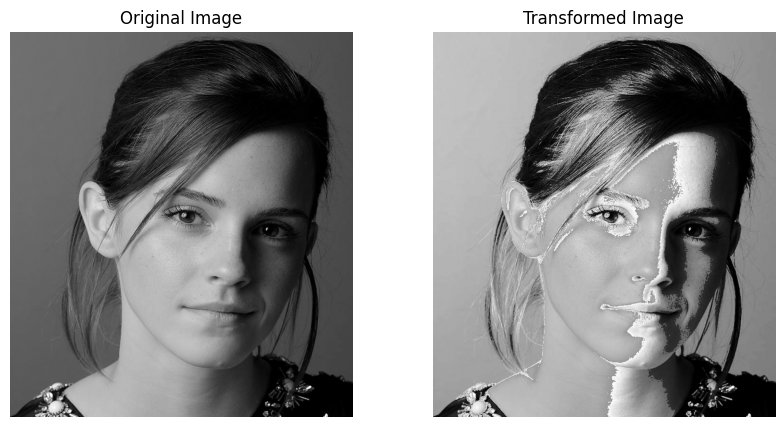

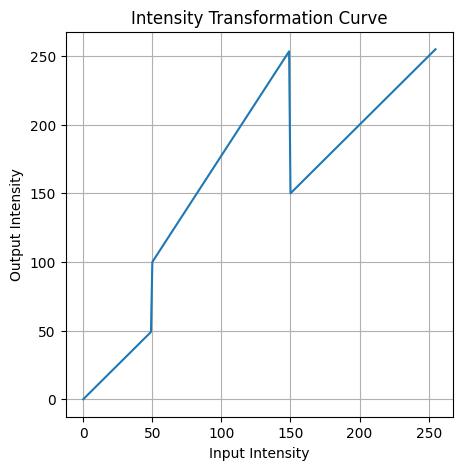

In [3]:
im = cv.imread('./images/emma.jpg', cv.IMREAD_GRAYSCALE)

def intensity_transformation(input):
    if input < 50:
        return input
    elif input <150:   # m=(255-100)/(150-100)=1.55 , c=100-1.55*50=22.5
        return (1.55 * input + 22.5)       
    else:
        return input

vect_transform = np.vectorize(intensity_transformation)
transformed_im = vect_transform(im).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(im, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Transformed Image')
plt.imshow(transformed_im, cmap='gray')
plt.axis('off')

plt.show()
input_intensity = np.arange(0, 256)
output_intensity = np.array([intensity_transformation(x) for x in input_intensity])
plt.figure(figsize=(5, 5))
plt.plot(input_intensity, output_intensity, label="Intensity Transformation")
plt.title('Intensity Transformation Curve')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.grid(True)
plt.show()


**Discussion:**

<img src="Q2.png" />

<img src="Q3.png" />

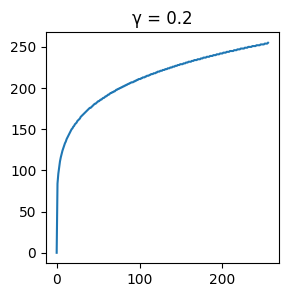

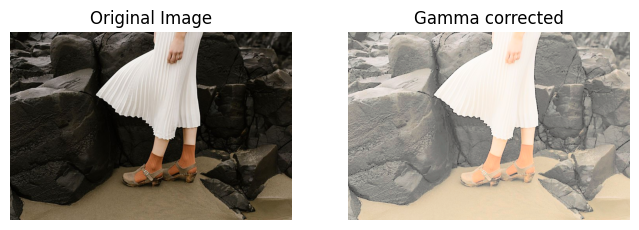

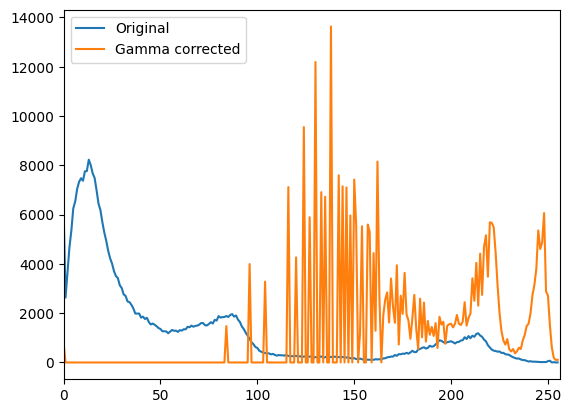

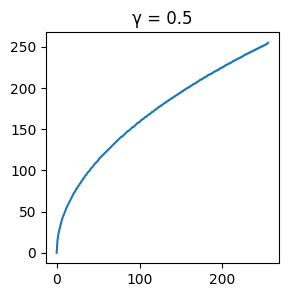

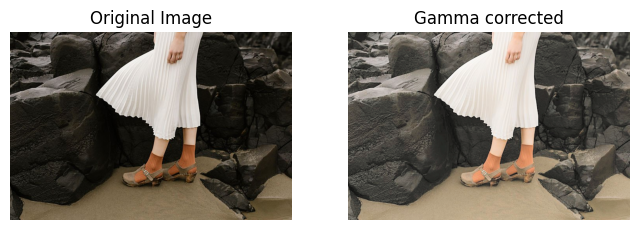

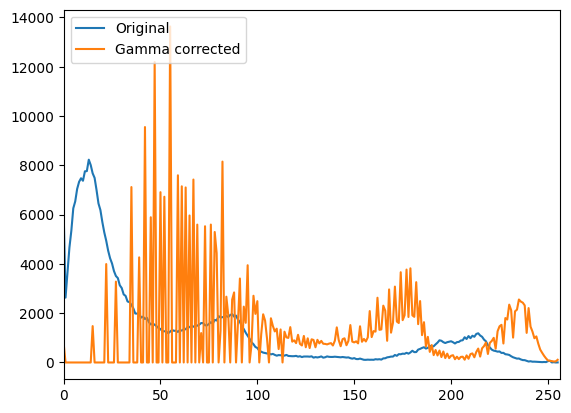

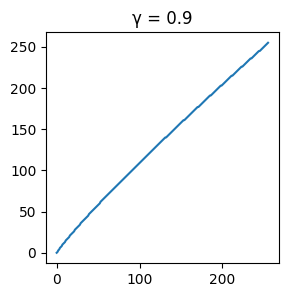

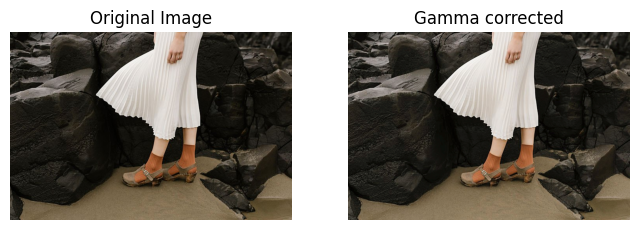

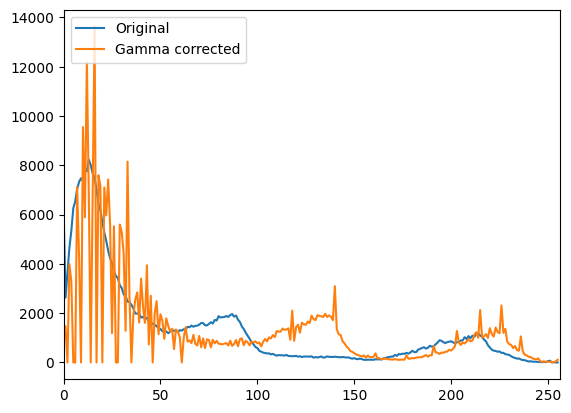

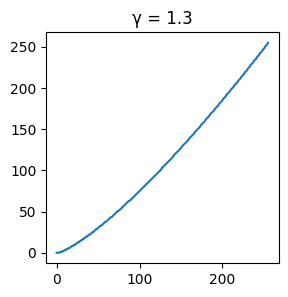

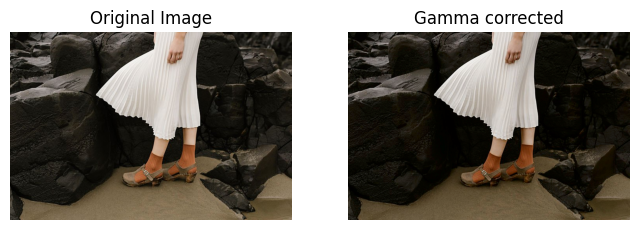

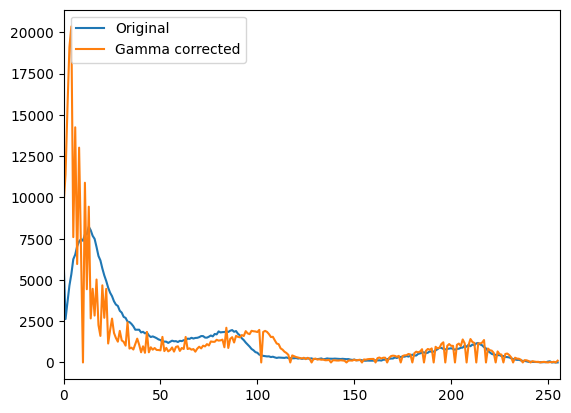

In [6]:
im = cv.imread("./images/highlights_and_shadows.jpg")
L, a, b = cv.split(cv.cvtColor(img, cv.COLOR_BGR2LAB))
gamma = [0.2, 0.5, 0.9, 1.3] 

for i in gamma:
    t = np.array([(p / 255) ** i * 255 for p in range(0, 256)]).astype(np.uint8)
    g = cv.LUT(L, t)
    corrected_img = cv.merge([g, a, b])
    hist1 = cv.calcHist([im], [0], None, [256], [0, 256])
    hist2 = cv.calcHist([corrected_img], [0], None, [256], [0, 256])
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.set_title("\u03B3 = " + str(i)) 
    ax.plot(t)
    fig, ax = plt.subplots(1, 2, figsize=(8, 8))

    ax[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    ax[1].imshow(cv.cvtColor(corrected_img, cv.COLOR_LAB2RGB))
    ax[1].set_title('Gamma corrected')
    ax[1].axis('off')

    plt.show()
    plt.plot(hist1) 
    plt.xlim([0, 256])

    plt.plot(hist2) 
    plt.xlim([0, 256])

    plt.legend(('Original', 'Gamma corrected'), loc='upper left')
    plt.show()



For gamma = 0.5 : Histograms for all 3 color planes before and after applying the correction

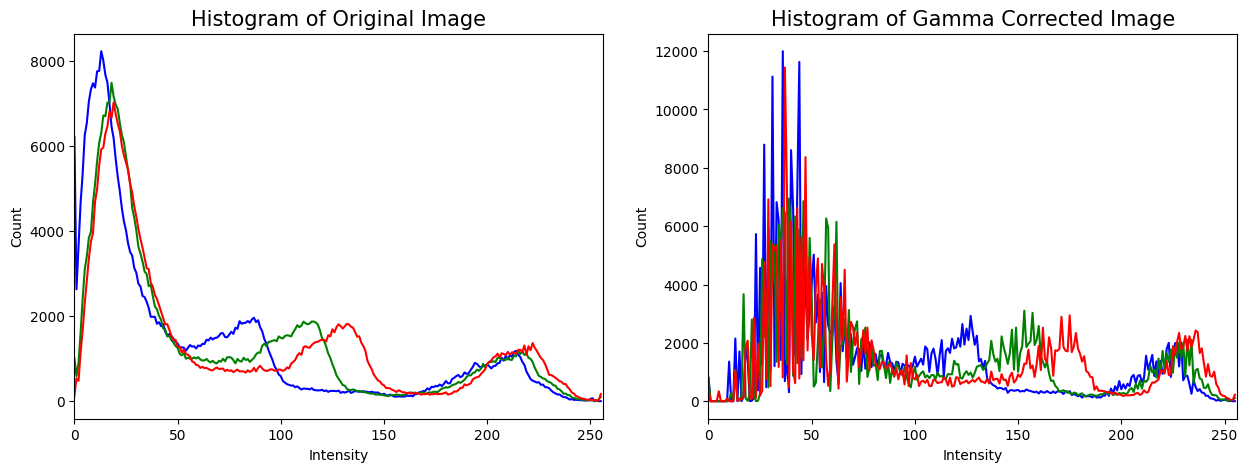

In [8]:
gamma = 0.6
gamma_transform = np.array([(i / 255.0) ** gamma * 255.0 for i in np.arange(0, 256)]).astype('uint8')
im_lab = cv.cvtColor(im, cv.COLOR_BGR2LAB)
im_lab[:, :, 0] = gamma_transform[im_lab[:, :, 0]]
def histBGR(img):
    colors = ('b', 'g', 'r')

    for i, color in enumerate(colors):
        hist = cv.calcHist([img], [i], None, [256], [0, 256])
        plt.plot(hist, color=color)

    plt.xlim([0, 256])

plt.figure(figsize=(15, 5)) 
plt.rc('axes', titlesize=15)  

plt.subplot(121)  
histBGR(im)  
plt.title("Histogram of Original Image")
plt.xlabel("Intensity")  
plt.ylabel("Count")  

plt.subplot(122)  
histBGR(cv.cvtColor(im_lab, cv.COLOR_LAB2BGR))  
plt.title("Histogram of Gamma Corrected Image")
plt.xlabel("Intensity")  
plt.ylabel("Count")  

plt.show()


<img src="Q4.png" />

<img src="Q5.png" />

<img src="Q6.png" />

<img src="Q7.png" />

<img src="Q8.png" />

<img src="Q9.png" />

<img src="Q10.png" />